In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
data = pd.read_csv("../data/processed/cleaning_data.csv")

In [26]:
data.head()

,age,gender,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,work_status,social_activity_level,exercise_frequency,meditation_or_mindfulness,diagnosis
0,56,Male,8.7,3.9,9.2,8.1,10.0,6.5,9.0,7.7,0,Working,Low,Daily,Yes,Depression
1,69,Male,1.3,9.9,4.2,9.9,20.0,7.0,41.0,8.4,1,Working,Low,Often,Yes,Both
2,46,Female,4.0,5.4,4.8,5.4,24.0,1.6,13.0,6.9,0,Partially working,Very low,Rarely,Yes,Depression
3,32,Female,9.4,2.1,2.9,3.8,10.0,6.8,11.0,7.5,0,Not working,High,Never,Yes,Depression
4,60,Female,7.6,7.5,6.4,8.5,17.0,7.0,46.0,3.1,1,Not working,Low,Rarely,No,Both


- b. Проведіть кодування (Categorical Encoding) категоріальних ознак

In [27]:
qualitative_features = data.select_dtypes(include=["object", "category"]).columns
quantitative_features = data.select_dtypes(include=["int64", "float64"]).columns

In [28]:
for feature in qualitative_features:
  print(data[feature].value_counts())
  print(" ")

gender
Male      524
Female    476
Name: count, dtype: int64
 
work_status
Partially working    382
Working              320
Not working          298
Name: count, dtype: int64
 
social_activity_level
Very low     243
High         200
Low          190
Very high    186
Medium       181
Name: count, dtype: int64
 
exercise_frequency
Rarely       249
Often        202
Daily        194
Sometimes    184
Never        171
Name: count, dtype: int64
 
meditation_or_mindfulness
Yes    516
No     484
Name: count, dtype: int64
 
diagnosis
Depression    401
ME/CFS        397
Both          202
Name: count, dtype: int64
 


Зробивши деякий аналіз даних, шо можу я сказати:
- категоріальна колонка `diagnosis` має 3 категорії, ну і логічно шо нам потрібно зберегти ціліність цільовї змінної, тому я використаю label encoding
- такі категорії як `gender`, `work_status`та `meditation_or_mindfulness` мають теж не багато категорій, тому можна спокійно використати one-hot encoding
- такі колонки як `exercise_frequency` та `social_activity_level` мають теж не багато категорій, але що важливіше - ми можемо побачити тут порядок, тобто одна категорія якось сильніше впливає на шось чим інша, тому я використаю ordinal encoding

In [29]:
def label_encoder(data, x):
    categories = data[x].value_counts().index.to_list()
    mapping = {cat: i for i, cat in enumerate(categories)}  
    data[x] = data[x].map(mapping) 

In [30]:
label_encoder(data, "diagnosis")

In [31]:
data["diagnosis"].value_counts()

diagnosis
0    401
1    397
2    202
Name: count, dtype: int64

In [32]:
ex_fr_values = ["Never", "Rarely", "Sometimes", "Often", "Daily"]
soc_act_values = ["Very low", "Low", "Medium", "High", "Very high"]

for categories, col in zip([ex_fr_values, soc_act_values], 
                           ["exercise_frequency", "social_activity_level"]):
    mapping = {cat: i for i, cat in enumerate(categories)}
    data[col] = data[col].map(mapping)

In [33]:
data[["exercise_frequency", "social_activity_level"]].head()

,exercise_frequency,social_activity_level
0,4,1
1,3,1
2,1,0
3,0,3
4,1,1


In [34]:
def one_hot_encoding(data, x):
    categories = data[x].unique()[1:]
    for category in categories:
        data[f"{x}_{category}"] = (data[x] == category).astype(int)
    data.drop(columns=[x], inplace=True)

In [35]:
for x in ["work_status", "gender", "meditation_or_mindfulness"]:
  one_hot_encoding(data, x)

In [36]:
data.columns

Index(['age', 'sleep_quality_index', 'brain_fog_level', 'physical_pain_score',
       'stress_level', 'depression_phq9_score', 'fatigue_severity_scale_score',
       'pem_duration_hours', 'hours_of_sleep_per_night', 'pem_present',
       'social_activity_level', 'exercise_frequency', 'diagnosis',
       'work_status_Partially working', 'work_status_Not working',
       'gender_Female', 'meditation_or_mindfulness_No'],
      dtype='object')

In [37]:
data["pem_present"] = data["pem_present"].astype(int)

In [38]:
data.head()

,age,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,social_activity_level,exercise_frequency,diagnosis,work_status_Partially working,work_status_Not working,gender_Female,meditation_or_mindfulness_No
0,56,8.7,3.9,9.2,8.1,10.0,6.5,9.0,7.7,0,1,4,0,0,0,0,0
1,69,1.3,9.9,4.2,9.9,20.0,7.0,41.0,8.4,1,1,3,2,0,0,0,0
2,46,4.0,5.4,4.8,5.4,24.0,1.6,13.0,6.9,0,0,1,0,1,0,1,0
3,32,9.4,2.1,2.9,3.8,10.0,6.8,11.0,7.5,0,3,0,0,0,1,1,0
4,60,7.6,7.5,6.4,8.5,17.0,7.0,46.0,3.1,1,1,1,2,0,1,1,1


- c. Опрацюйте аномальні значення

In [39]:
def plot_boxplots():
    quantitative_features = data.drop(columns=["diagnosis"]).columns
    n = len(quantitative_features)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

    if n_rows * n_cols == 1:
        ax = [ax] 
    else:
        ax = ax.flatten()

    for i, x in enumerate(quantitative_features):
        sns.boxplot(data=data, x=x, color="skyblue", ax=ax[i])
        ax[i].set_title(x)

    for j in range(n, n_rows * n_cols):
        ax[j].set_visible(False)

    plt.tight_layout()
    plt.show()

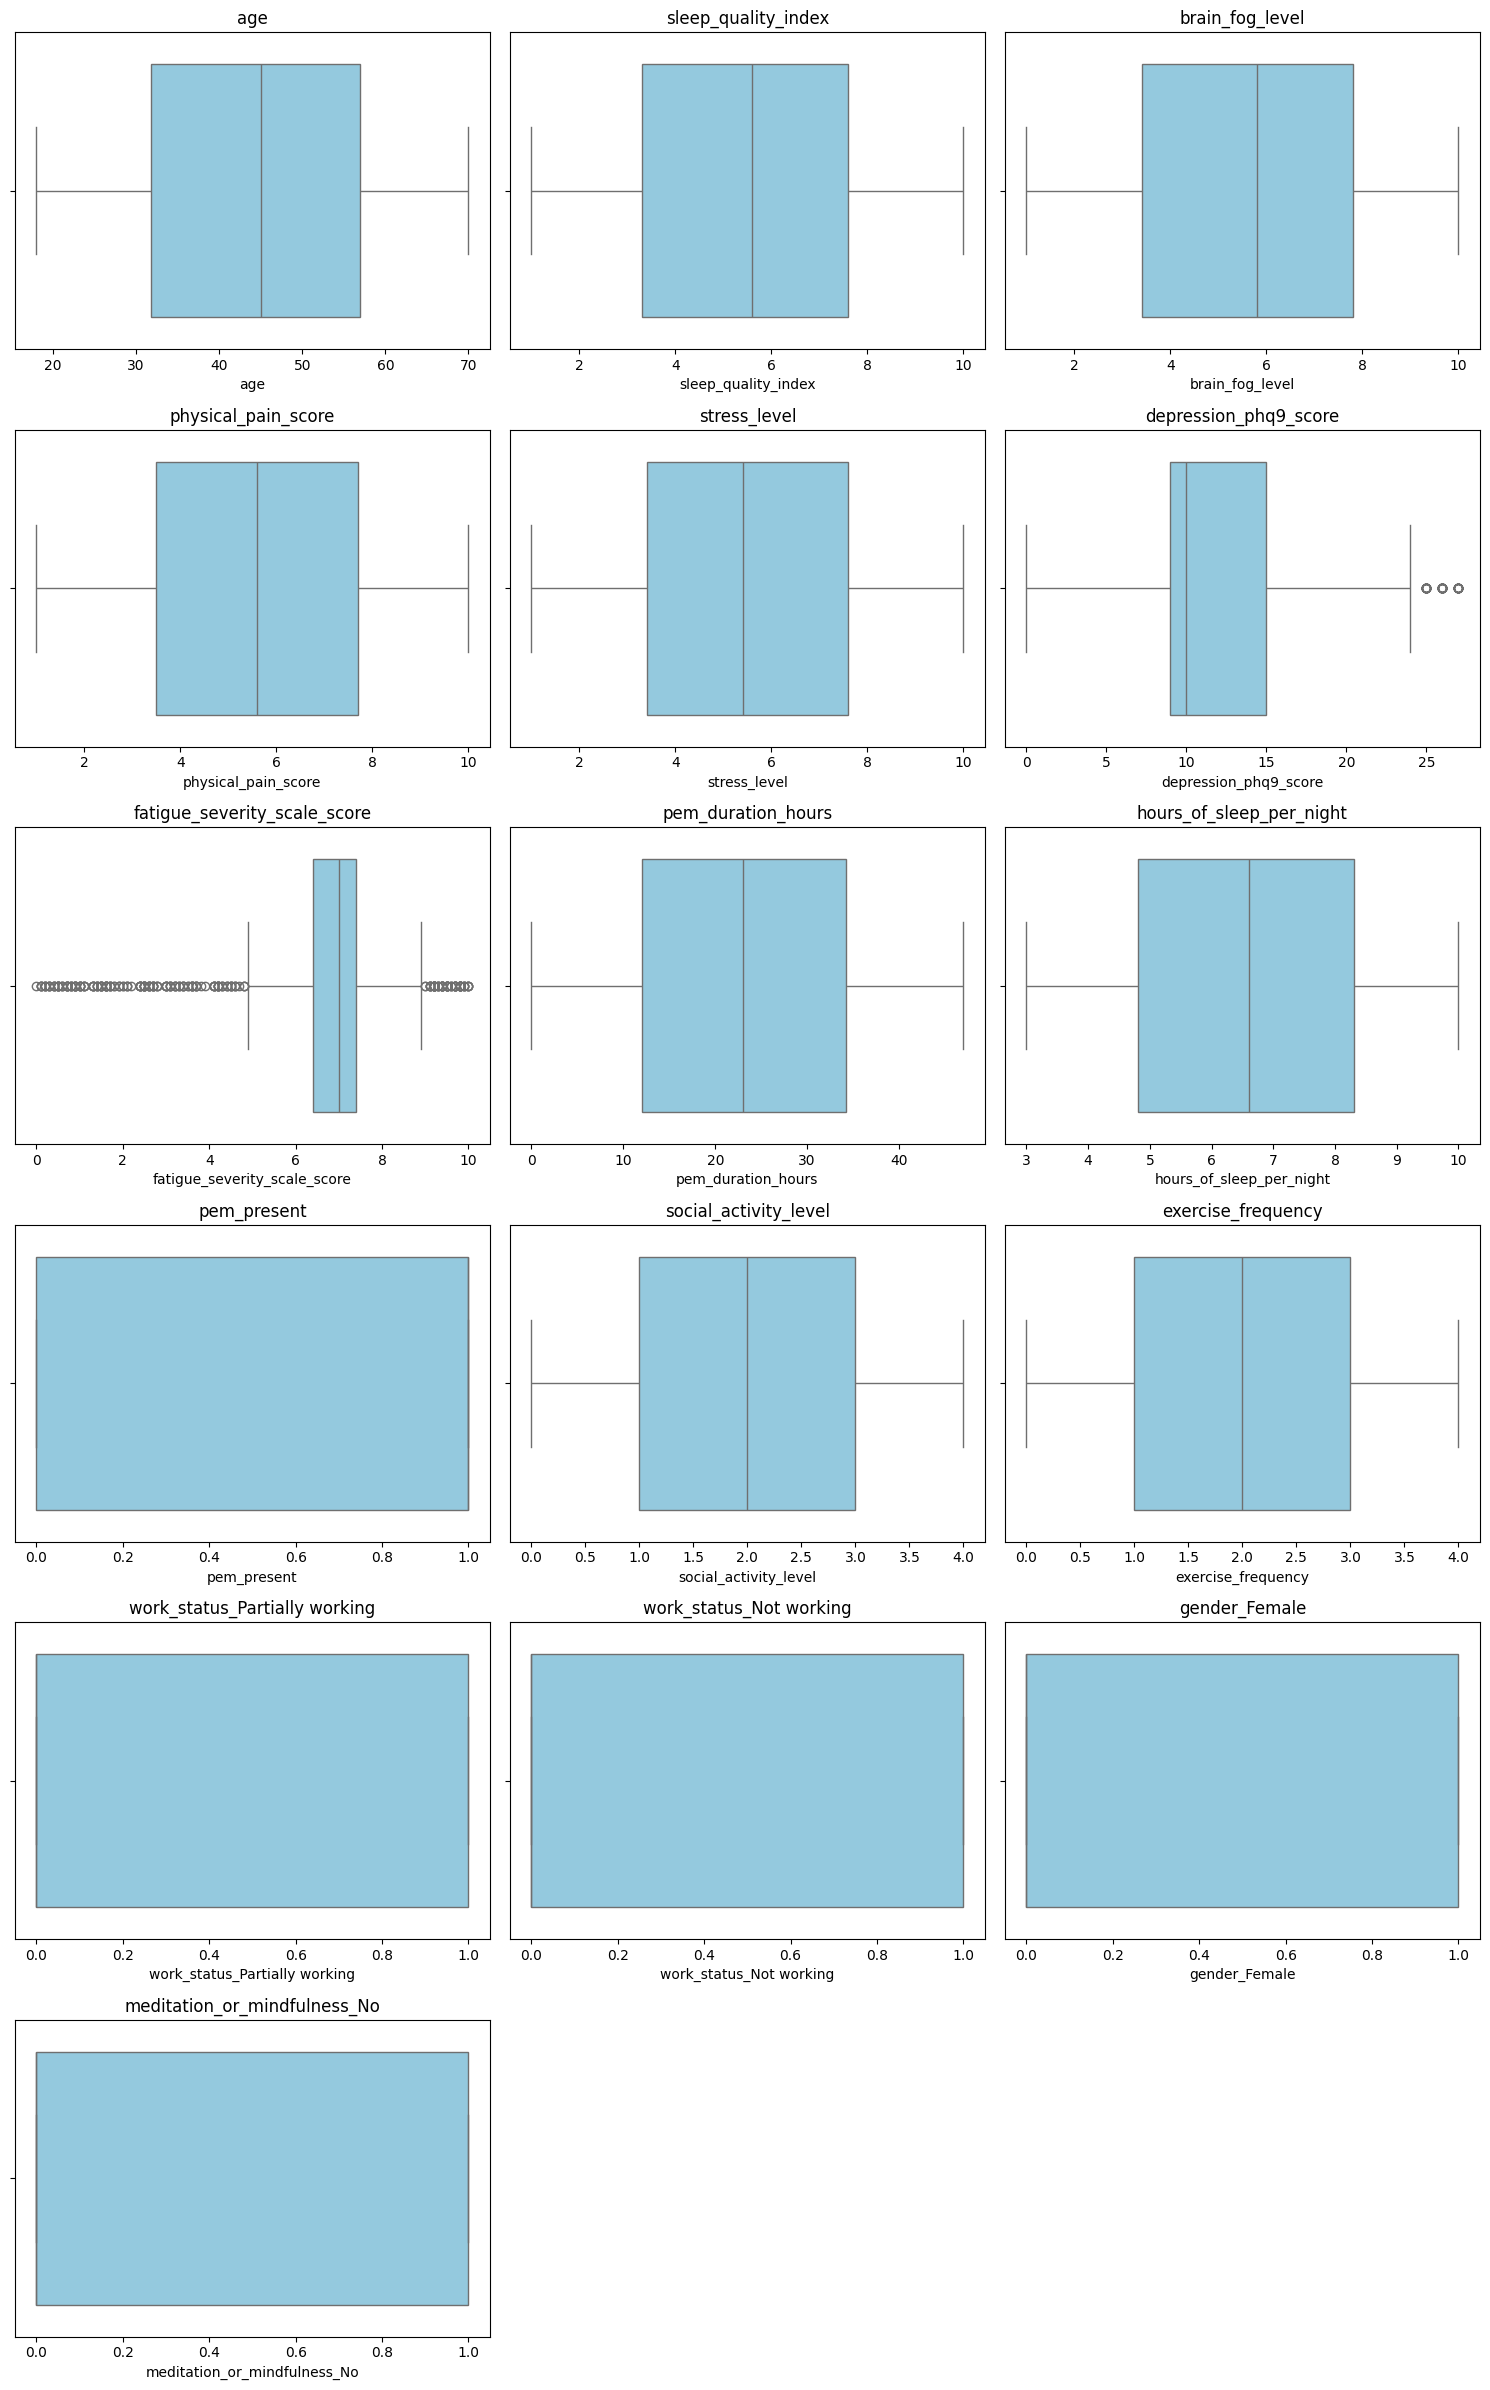

In [40]:
plot_boxplots()

Ми бачимо шо в фічах `fatigue_severity_scale_score` та `depression_ph9_score` мають викиди

In [41]:
Q1 = data['fatigue_severity_scale_score'].quantile(0.25)
Q3 = data['fatigue_severity_scale_score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['fatigue_severity_scale_score'] < lower) |
                (data['fatigue_severity_scale_score'] > upper)]

print(f"Кількість викидів: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
print(f"Мін: {outliers['fatigue_severity_scale_score'].min()}")
print(f"Макс: {outliers['fatigue_severity_scale_score'].max()}")
print(f"Середнє: {outliers['fatigue_severity_scale_score'].mean()}")
print(f"Медіана: {outliers['fatigue_severity_scale_score'].median()}")
print(f"Рядки з викидами (перші 10):\n{outliers[['fatigue_severity_scale_score']].head(10)}")


Кількість викидів: 238 (23.80%)
Мін: 0.0
Макс: 10.0
Середнє: 4.167226890756303
Медіана: 3.05
Рядки з викидами (перші 10):
    fatigue_severity_scale_score
2                            1.6
7                            4.5
9                            9.8
17                           9.0
18                           1.0
26                           3.0
29                           0.9
55                           1.6
58                           9.8
59                           9.9


In [42]:
Q1 = data['depression_phq9_score'].quantile(0.25)
Q3 = data['depression_phq9_score'].quantile(0.75)
IQR = Q3 - Q1

# Межі для викидів
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['depression_phq9_score'] < lower) |
                (data['depression_phq9_score'] > upper)]

print(f"Кількість викидів: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
print(f"Мін: {outliers['depression_phq9_score'].min()}")
print(f"Макс: {outliers['depression_phq9_score'].max()}")
print(f"Середнє: {outliers['depression_phq9_score'].mean()}")
print(f"Медіана: {outliers['depression_phq9_score'].median()}")
print(f"Рядки з викидами:\n{outliers[['depression_phq9_score']].head(10)}")  


Кількість викидів: 70 (7.00%)
Мін: 25.0
Макс: 27.0
Середнє: 25.928571428571427
Медіана: 26.0
Рядки з викидами:
     depression_phq9_score
15                    26.0
16                    25.0
22                    27.0
32                    25.0
38                    27.0
57                    27.0
68                    25.0
81                    26.0
102                   27.0
114                   25.0


Fatigue Severity Scale (FSS): Є 238 аномальних значень (~24%), включно з дуже низькими (0–1.6) і високими (9–10). Це можуть бути реальні екстремальні стани пацієнтів, не помилки.
Depression PHQ-9: Є 70 аномальних значень (~7%), всі високі (25–27). Це також можуть бути реальні прояви сильної депресії. 

Так, як даних в мене не багато, а в аутлаєрах я бачу шо це реально можливі такі випадки, то я роблю рішення нічого не видаляти та залишити дані.

- d. Використайте підходи масштабування ознак якщо це доцільно для
ваших даних

In [43]:
data.head()

,age,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,social_activity_level,exercise_frequency,diagnosis,work_status_Partially working,work_status_Not working,gender_Female,meditation_or_mindfulness_No
0,56,8.7,3.9,9.2,8.1,10.0,6.5,9.0,7.7,0,1,4,0,0,0,0,0
1,69,1.3,9.9,4.2,9.9,20.0,7.0,41.0,8.4,1,1,3,2,0,0,0,0
2,46,4.0,5.4,4.8,5.4,24.0,1.6,13.0,6.9,0,0,1,0,1,0,1,0
3,32,9.4,2.1,2.9,3.8,10.0,6.8,11.0,7.5,0,3,0,0,0,1,1,0
4,60,7.6,7.5,6.4,8.5,17.0,7.0,46.0,3.1,1,1,1,2,0,1,1,1


В даних я бачу, шо є деякі колонки в яких числа є більші чи менші за інші, такі як: \
age → 32–69 \
pem_duration_hours → 9–46 \
fatigue_severity_scale_score, brain_fog_level, stress_level → 0–10

Також, як було описано вище, в датасеті є явні викиди, які можуть повпливати на роботу моделі, тому масштабування даних було б непоганим останнім кроком перед моделюванням.

До того ж, я ще не знаю яку модель буду використоувати, а такі KNN чи SVM і так далі є доволі чутливими до немасштабованих даних

Тому, знаючи шо присутні викид та шоб знизити їх вплив можна використати RobustScaler

In [44]:
from sklearn.preprocessing import RobustScaler

In [45]:
scaler = RobustScaler()

quantitative_features = quantitative_features.to_list()

data[quantitative_features] = scaler.fit_transform(data[quantitative_features])
data.head()

,age,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,social_activity_level,exercise_frequency,diagnosis,work_status_Partially working,work_status_Not working,gender_Female,meditation_or_mindfulness_No
0,0.435644,0.720930,-0.431818,0.857143,0.642857,0.000000,-0.5,-0.629213,0.314286,-1.0,1,4,0,0,0,0,0
1,0.950495,-1.000000,0.931818,-0.333333,1.071429,1.666667,0.0,0.808989,0.514286,0.0,1,3,2,0,0,0,0
2,0.039604,-0.372093,-0.090909,-0.190476,0.000000,2.333333,-5.4,-0.449438,0.085714,-1.0,0,1,0,1,0,1,0
3,-0.514851,0.883721,-0.840909,-0.642857,-0.380952,0.000000,-0.2,-0.539326,0.257143,-1.0,3,0,0,0,1,1,0
4,0.594059,0.465116,0.386364,0.190476,0.738095,1.166667,0.0,1.033708,-1.000000,0.0,1,1,2,0,1,1,1


In [46]:
data.to_csv("../data/processed/feature_engineered_data.csv", index=False)

---
2. Сформуйте “Звіт про очищення даних”
----

Я виконав 4 етапи опрацювання даних:

- Опрацювання відсутніх значень: для числових та категоріальнмх фіч було перевірено наявність пропусків.
Були знайдені пропупски в таких колонках як: \
`fatigue_severity_scale_score`    2.1 \
`depression_phq9_score`           2.2 \
`pem_duration_hours`              2.4 \
`brain_fog_level`                 4.8 \
`physical_pain_score`             3.4 \
`stress_level`                    4.8 \
`hours_of_sleep_per_night`        2.1 \
`diagnosis`                       0.0 \
`work_status`                     4.7 \
`social_activity_level`           4.0 \
`exercise_frequency`              3.9 
Дослідивши графіки та провівши аналіз, я зробив median imputation для числових колонок та mode imputation для категоріальних

- Енкодинг категоріальних змінних
У процесі підготовки даних я виконав енкодинг категоріальних змінних з урахуванням їхніх особливостей. Цільова змінна `diagnosis` має три категорії, тому для збереження її цілісності я застосував Label Encoding. Змінні `gender`, `work_status` та `meditation_or_mindfulness` не мають природного порядку й містять невелику кількість категорій, тому для них я використав One-Hot Encoding (у форматі k–1 dummy змінних). Натомість у змінних `exercise_frequency` та `social_activity_level` є чіткий порядок між категоріями (наприклад, від "Never" до "Daily" чи від "Very low" до "Very high"), тому я застосував Ordinal Encoding з визначенням відповідної послідовності. Такий підхід дозволив мені зберегти максимально можливу інформацію та підготувати дані до подальшого моделювання. 

- Опрацювання аномалій: виконано аналіз викидів методом IQR (Interquartile Range).
Fatigue Severity Scale (FSS):
Виявлено ~24% екстремальних значень (0–1.6 та 9–10).
Це реальні клінічні стани пацієнтів → залишено в даних.
Depression PHQ-9:
Виявлено ~7% аномальних значень (25–27).
Це прояви важкої депресії → залишено в даних.
Викиди збережено, бо вони несуть медичну цінність, але при потребі можна опрацювати їх, якшо модель буде чутлива до викидів.

- Масштабування: Для всіх числових ознак  застосовано RobustScaler, оскільки це зменшує розкид між ознаками,
RobustScaler менш чутливий до викидів (на відміну від StandardScaler). Це особливо важливо, оскільки дані містять клінічно значимі екстремальні значення.

---
3. Обґрунтуйте методи інженерії даних, які були використані для підготовки 
даних вашого підприємства.
----

Я використав `median imputer`, оскільки частина числових змінних мала перекошений розподіл, і медіана краще відображає центральну тенденцію без впливу викидів(а в мене вони були). Для категоріальних змінних я застосував `mode imputer`, тому що найбільш поширене значення найкраще замінює пропуски без спотворення структури даних, а в мене вони були приьлмзно нормально розподілені та пропусків не багато. 'One-hot encoding' я використав для номінативних змінних без порядку, щоб зберегти інформацію, і до того ж це не сильно додало мені багато колонок. `Label encoding` застосував лише до цільової змінної, щоб закодувати категорії у зручний числовий формат. Для змінних із чітким порядком категорій я використав `ordinal encoding`, бо він дозволяє зберегти ієрархію між значеннями. І нарешті, я обрав `RobustScaler` для масштабування числових змінних, бо він менш чутливий до викидів і забезпечує стабільніше перетворення даних.

Загалом, мені сподобалася лабораторна, досліджувати дані, думати над тим, який саме підхід обрати для конкретного випадку, а також мені це допомогло практично засвоїти деякі підходи, які я застосував практично 

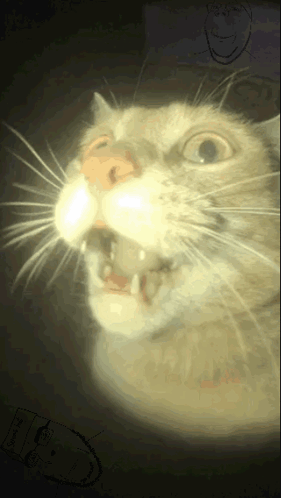